In [21]:
#Code block to connect to API and get the last 2 days of data 
#API infos : 
#import requests
#import os
#api_key = os.environ.get("API_KEY")
#headers = {
#    "Authorization": f"Apikey {api_key}",
#    "Content-Type": "application/json"
#}
#response = requests.get("https://data.bs.ch/api/explore/v2.1/catalog/datasets/100089/records/?lang=en&limit=10&offset=0", headers=headers)
#Data received : Field
#  Identifier Type
#1	Zeitstempel	timestamp	Datetime	
#2	Abflussmenge	abfluss	Decimal	
#3	Pegel	pegelhoehe	Decimal	
#4	Wasserstand	pegel	Decimal	



In [30]:
import os
from datetime import datetime, timedelta, timezone

import pandas as pd
import requests

DATASET_URL = "https://data.bs.ch/api/explore/v2.1/catalog/datasets/100089/records"
PAGE_SIZE = 100  # max allowed by the Explore API v2.1


def get_last_2_days(days=2, api_key=None):
    """Fetch the last `days` days of Rhein measurements from data.bs.ch (dataset 100089).

    Returns a DataFrame with columns: timestamp (UTC-aware), abfluss, pegelhoehe, pegel,
    sorted oldest -> newest. Records come at 5-minute intervals (~576 rows for 2 days).
    """
    api_key = api_key or os.environ.get("API_KEY")
    headers = {"Content-Type": "application/json"}
    if api_key:
        headers["Authorization"] = f"Apikey {api_key}"

    since = datetime.now(timezone.utc) - timedelta(days=days)

    rows, offset = [], 0
    while True:
        params = {
            "where": f"timestamp >= date'{since.strftime('%Y-%m-%dT%H:%M:%S')}'",
            "order_by": "timestamp asc",
            "limit": PAGE_SIZE,
            "offset": offset,
        }
        response = requests.get(DATASET_URL, headers=headers, params=params, timeout=30)
        response.raise_for_status()
        results = response.json().get("results", [])
        rows.extend(results)
        if len(results) < PAGE_SIZE:
            break
        offset += PAGE_SIZE

    df = pd.DataFrame(rows, columns=["timestamp", "abfluss", "pegelhoehe", "pegel"])
    if not df.empty:
        df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True)
        df = df.sort_values("timestamp").reset_index(drop=True)
    return df


df = get_last_2_days()
print(f"{len(df)} rows from {df['timestamp'].min()} to {df['timestamp'].max()}")
df.head()
df.tail()

574 rows from 2026-10-01 14:35:00+00:00 to 2026-10-03 14:20:00+00:00


,timestamp,abfluss,pegelhoehe,pegel
569,2026-10-03 14:00:00+00:00,347.051,479.1,244.791
570,2026-10-03 14:05:00+00:00,343.248,478.6,244.786
571,2026-10-03 14:10:00+00:00,333.340,477.3,244.773
572,2026-10-03 14:15:00+00:00,334.103,477.4,244.774
573,2026-10-03 14:20:00+00:00,344.009,478.7,244.787


In [23]:
#Specific thresholds for Basel Rheinhalle station : 
#Critical, no navigation allowed, too high : pegelhoehe > 790 (Official Marke 2 restrictions)
#Warning, limited navigation (level 3), water level too high : pegelhoehe > 700 (Offical Marke 1 restrictions) 
#Warning, limited navigation (level 2), water level too high : pegelhoehe > 670 (boat length restricted - max 135 m)
#Warning, limited naviation (level 1), water level too high : pegelhoehe > 620 (boat length restricted - max 125 m)
#Warning, limited navigation, water level too low : pegelhoehe - 246 < 350 (max boat load not possible for ref boat with 350m draft)
#Critical, no navigation for economical reasons, water level too low : pegelhoehe - 246 <230 (less than 50% boat loat possible for ref boat with 350m draft)

In [32]:
from collections.abc import Mapping

import math

MARGIN_CM = 5.0  # fixed 5 cm band around every threshold
DRAFT_OFFSET = 246  # cm; available draft (Abladetiefe) = pegelhoehe - 246

# Basel Rheinhalle, high water. Checked against `pegelhoehe` [cm], most severe first.
HIGH_THRESHOLDS = [
    {"limit": 790, "severity": "critical", "label": "Marke 2",
     "consequence": "no navigation allowed", "short": "Marke 2\nno navigation"},
    {"limit": 700, "severity": "warning", "label": "level 3 (Marke 1)",
     "consequence": "limited navigation", "short": "Marke 1\nlimited navigation"},
    {"limit": 670, "severity": "warning", "label": "level 2",
     "consequence": "boat length limited to 135 m", "short": "max boat\nlength 135 m"},
    {"limit": 620, "severity": "warning", "label": "level 1",
     "consequence": "boat length limited to 125 m", "short": "max boat\nlength 125 m"},
]

# Basel Rheinhalle, low water. Checked against the available draft [cm], most severe first.
LOW_THRESHOLDS = [
    {"limit": 230, "severity": "critical", "label": "uneconomical",
     "consequence": "less than 50% load for the 350 cm draft reference boat",
     "short": "under 50%\nload"},
    {"limit": 350, "severity": "warning", "label": "reduced load",
     "consequence": "max load not possible for the 350 cm draft reference boat",
     "short": "reduced\nload"},
]

_RANK = {"normal": 0, "watch": 1, "warning": 2, "critical": 3}


def _classify(value, limit, too_high):
    """Return (state, distance) where state is 'ok', 'margin' or 'breached'.

    'margin'   -> inside the 5 cm band, warning that the threshold is close
    'breached' -> past the threshold. The margin does NOT soften a crossing:
                  once a limit is crossed it is simply crossed.
    """
    gap = (value - limit) if too_high else (limit - value)  # >0 means the limit is crossed
    if gap > 0:
        return "breached", gap
    if -gap <= MARGIN_CM:
        return "margin", abs(gap)
    return "ok", abs(gap)


def _check_family(value, thresholds, quantity, too_high):
    """Walk thresholds most-severe-first, stopping after the first crossed one."""
    findings = []
    for rule in thresholds:
        state, distance = _classify(value, rule["limit"], too_high)
        if state == "ok":
            continue
        direction = "above" if too_high else "below"
        if state == "breached":
            text = (f"{quantity} {value:.1f} cm is {distance:.1f} cm {direction} the "
                    f"{rule['severity']} threshold of {rule['limit']} cm "
                    f"[{rule['label']}] -> {rule['consequence']}")
        else:
            text = (f"{quantity} {value:.1f} cm is within the {MARGIN_CM:.0f} cm margin of the "
                    f"{rule['severity']} threshold of {rule['limit']} cm [{rule['label']}], "
                    f"{distance:.1f} cm to go -> would mean: {rule['consequence']}")
        findings.append({
            "quantity": quantity,
            "value": value,
            "limit": rule["limit"],
            "label": rule["label"],
            "severity": rule["severity"],
            "state": state,
            "distance_cm": distance,
            "consequence": rule["consequence"],
            "message": text,
        })
        if state == "breached":
            break  # less severe thresholds below this one are implied
    return findings


def assess_conditions(measurement):
    """Judge one measurement against the Basel Rheinhalle navigation thresholds.

    `measurement` is a row of the DataFrame (dict or pandas Series), or a bare
    pegelhoehe value in cm.

    Returns a dict with:
      status   'normal' | 'watch' | 'warning' | 'critical'
      normal   True only when status == 'normal'
      findings list of everything that is not normal, most severe first
      summary  printable text
    """
    if isinstance(measurement, Mapping) or hasattr(measurement, "index"):
        pegelhoehe = measurement["pegelhoehe"]
        timestamp = measurement["timestamp"] if "timestamp" in measurement else None
    else:
        pegelhoehe, timestamp = measurement, None

    if pegelhoehe is None or (isinstance(pegelhoehe, float) and math.isnan(pegelhoehe)):
        return {"status": "unknown", "normal": False, "timestamp": timestamp,
                "pegelhoehe": None, "draft_cm": None, "findings": [],
                "summary": "No pegelhoehe in this measurement - cannot assess."}

    pegelhoehe = float(pegelhoehe)
    draft = pegelhoehe - DRAFT_OFFSET

    findings = (_check_family(pegelhoehe, HIGH_THRESHOLDS, "water level", too_high=True)
                + _check_family(draft, LOW_THRESHOLDS, "available draft", too_high=False))

    status = "normal"
    for f in findings:
        level = f["severity"] if f["state"] == "breached" else "watch"
        if _RANK[level] > _RANK[status]:
            status = level
    findings.sort(key=lambda f: -_RANK[f["severity"] if f["state"] == "breached" else "watch"])

    head = f"[{status.upper()}] water level {pegelhoehe:.1f} cm, available draft {draft:.1f} cm"
    if timestamp is not None:
        head += f" at {timestamp}"
    if status == "normal":
        body = ["Conditions are normal: no threshold crossed and none within the "
                f"{MARGIN_CM:.0f} cm margin."]
    else:
        body = [("  - CROSSED: " if f["state"] == "breached" else "  - NEAR:    ") + f["message"]
                for f in findings]

    return {
        "status": status,
        "normal": status == "normal",
        "timestamp": timestamp,
        "pegelhoehe": pegelhoehe,
        "draft_cm": draft,
        "findings": findings,
        "summary": "\n".join([head] + body),
    }


print(assess_conditions(df.iloc[-1])["summary"])


[WARNING] water level 478.7 cm, available draft 232.7 cm at 2026-10-03 14:20:00+00:00
  - CROSSED: available draft 232.7 cm is 117.3 cm below the warning threshold of 350 cm [reduced load] -> max load not possible for the 350 cm draft reference boat
  - NEAR:    available draft 232.7 cm is within the 5 cm margin of the critical threshold of 230 cm [uneconomical], 2.7 cm to go -> would mean: less than 50% load for the 350 cm draft reference boat


In [25]:
assess_conditions(df.iloc[-1])


{'status': 'warning',
 'normal': False,
 'timestamp': Timestamp('2026-10-03 13:50:00+0000', tz='UTC'),
 'pegelhoehe': 480.7999999999993,
 'draft_cm': 234.79999999999927,
 'findings': [{'quantity': 'available draft',
   'value': 234.79999999999927,
   'limit': 350,
   'label': 'reduced load',
   'severity': 'warning',
   'state': 'breached',
   'distance_cm': 115.20000000000073,
   'consequence': 'max load not possible for the 350 cm draft reference boat',
   'message': 'available draft 234.8 cm is 115.2 cm below the warning threshold of 350 cm [reduced load] -> max load not possible for the 350 cm draft reference boat'},
  {'quantity': 'available draft',
   'value': 234.79999999999927,
   'limit': 230,
   'label': 'uneconomical',
   'severity': 'critical',
   'state': 'margin',
   'distance_cm': 4.799999999999272,
   'consequence': 'less than 50% load for the 350 cm draft reference boat',
   'message': 'available draft 234.8 cm is within the 5 cm margin of the critical threshold of 230

In [33]:
# Official BAFU ensemble forecast for Basel Rheinhalle (station 2289).
# The hydrodaten.admin.ch station page draws its forecast from a Plotly figure that is
# served as JSON - same numbers as the published plot, no scraping of pixels:
#   https://www.hydrodaten.admin.ch/plots/q_forecast/2289_q_forecast_en.json   (discharge, m3/s)
#   https://www.hydrodaten.admin.ch/plots/p_forecast/2289_p_forecast_en.json   (level, m a.s.l.)
# Traces: Median, Min/Max (two bounds), 25.-75. percentile (a closed polygon),
# and Measured for the preceding 24 h. Hourly steps, ~5 days ahead.

BAFU_STATION = 2289
BAFU_PLOT_URL = "https://www.hydrodaten.admin.ch/plots/{kind}/{station}_{kind}_{lang}.json"
BAFU_KINDS = {"discharge": "q_forecast", "level": "p_forecast"}
# Gauge zero at Basel Rheinhalle, verified against the data.bs.ch series:
# pegelhoehe[cm] == (pegel[m a.s.l.] - 240.00) * 100 exactly, for every row.
GAUGE_DATUM_M = 240.00


def _plotly_traces(fig):
    """Split the forecast figure into median / bounds / band / measured traces."""
    traces = fig["plot"]["data"]
    median = next(t for t in traces if "median" in (t.get("name") or "").lower())
    n = len(median["x"])
    measured, bounds, band = None, [], None
    for trace in traces:
        if trace is median:
            continue
        name = (trace.get("name") or "").lower()
        if any(k in name for k in ("measured", "gemessen", "mesur", "misur")):
            measured = trace
        elif len(trace["x"]) == 2 * n + 1:  # closed polygon: edge, reversed edge, close
            band = ([float(v) for v in trace["y"][:n]],
                    [float(v) for v in trace["y"][n:2 * n]][::-1])
        elif len(trace["x"]) == n:
            bounds.append([float(v) for v in trace["y"]])
    return median, bounds, band, measured


def get_bafu_forecast(station=BAFU_STATION, variable="level", lang="en",
                      datum_m=GAUGE_DATUM_M):
    """Fetch the official BAFU ensemble forecast for one station.

    variable 'level'     -> converted to pegelhoehe [cm], directly comparable to the
                            thresholds and to the data.bs.ch series
             'discharge' -> left in m3/s

    Returns a DataFrame (timestamp, median, p25, p75, min, max) with
    df.attrs holding 'title', 'issued', 'unit', 'station', 'variable' and
    'measured' (the observed last 24 h, same units).
    """
    if variable not in BAFU_KINDS:
        raise ValueError(f"variable must be one of {sorted(BAFU_KINDS)}")
    url = BAFU_PLOT_URL.format(kind=BAFU_KINDS[variable], station=station, lang=lang)
    response = requests.get(url, timeout=30)
    if response.status_code == 404:
        raise LookupError(f"no {variable} forecast published for station {station}")
    response.raise_for_status()
    fig = response.json()

    median, bounds, band, measured = _plotly_traces(fig)
    to_cm = (lambda v: (v - datum_m) * 100.0) if variable == "level" else (lambda v: v)

    out = pd.DataFrame({
        "timestamp": pd.to_datetime(median["x"], utc=True),
        "median": [to_cm(float(v)) for v in median["y"]],
    })
    if band:
        lo, hi = band
        out["p25"] = [to_cm(min(a, b)) for a, b in zip(lo, hi)]
        out["p75"] = [to_cm(max(a, b)) for a, b in zip(lo, hi)]
    if len(bounds) == 2:
        out["min"] = [to_cm(min(a, b)) for a, b in zip(*bounds)]
        out["max"] = [to_cm(max(a, b)) for a, b in zip(*bounds)]

    observed = pd.DataFrame(columns=["timestamp", "value"])
    if measured is not None:
        observed = pd.DataFrame({
            "timestamp": pd.to_datetime(measured["x"], utc=True),
            "value": [to_cm(float(v)) for v in measured["y"]],
        }).dropna()

    layout = fig["plot"]["layout"]
    issued = next((a.get("text") for a in layout.get("annotations", [])
                   if "forecast" in (a.get("text") or "").lower()
                   or "vorhersage" in (a.get("text") or "").lower()), None)
    out.attrs.update({
        "title": layout.get("title"),
        "issued": issued,
        "unit": "cm (pegelhoehe)" if variable == "level" else "m3/s",
        "station": station,
        "variable": variable,
        "source": url,
        "measured": observed,
    })
    return out


def forecast_conditions_bafu(df=None, days_ahead=5, station=BAFU_STATION, lang="en"):
    """Assess now vs. `days_ahead` ahead using the official BAFU ensemble forecast.

    Returns `latest` and `forecast` (each with timestamp, pegelhoehe and its
    assessment), `band` (the assessment of the ensemble envelope at the horizon),
    `first_crossings` (when the median first reaches each status), the full
    `series`, and a printable `summary`.
    """
    forecast = get_bafu_forecast(station=station, variable="level", lang=lang)
    if forecast.empty:
        raise LookupError("forecast came back empty")

    if df is not None and not df.empty:
        latest_row = df.dropna(subset=["pegelhoehe"]).sort_values("timestamp").iloc[-1]
        latest = {"timestamp": latest_row["timestamp"],
                  "pegelhoehe": float(latest_row["pegelhoehe"])}
        source_now = "data.bs.ch"
    else:
        observed = forecast.attrs["measured"]
        latest = {"timestamp": observed["timestamp"].iloc[-1],
                  "pegelhoehe": float(observed["value"].iloc[-1])}
        source_now = "BAFU measured"

    wanted = latest["timestamp"] + pd.Timedelta(days=days_ahead)
    horizon_end = forecast["timestamp"].iloc[-1]
    truncated = wanted > horizon_end
    row = forecast.iloc[(forecast["timestamp"] - wanted).abs().argmin()]

    latest_assessment = assess_conditions(latest)
    forecast_assessment = assess_conditions({"timestamp": row["timestamp"],
                                             "pegelhoehe": float(row["median"])})
    band = {}
    for key in ("min", "p25", "p75", "max"):
        if key in forecast.columns:
            band[key] = assess_conditions({"timestamp": row["timestamp"],
                                           "pegelhoehe": float(row[key])})

    statuses = [assess_conditions(float(v))["status"] for v in forecast["median"]]
    first_crossings = {}
    for status, timestamp in zip(statuses, forecast["timestamp"]):
        first_crossings.setdefault(status, timestamp)

    lines = [
        f"BAFU station {station} - {forecast.attrs['title']}",
        f"{forecast.attrs['issued']}, horizon {forecast['timestamp'].iloc[0]} -> {horizon_end}",
        f"Now ({source_now}) {latest['pegelhoehe']:.1f} cm -> "
        f"{row['median']:.1f} cm median at {row['timestamp']}",
    ]
    if band:
        lines.append("  ensemble at that time: "
                     + ", ".join(f"{k} {float(row[k]):.1f} cm [{band[k]['status']}]"
                                 for k in band))
    if truncated:
        lines.append(f"NOTE: the forecast only reaches {horizon_end}, short of the "
                     f"{days_ahead}-day horizon - reporting its last step instead.")
    if first_crossings:
        lines.append("  median status timeline, first occurrence of each "
                     "(the earliest may already hold at the forecast start): "
                     + ", ".join(f"{s} at {t}" for s, t in first_crossings.items()))
    summary = "\n".join(lines + [
        "", "NOW:", latest_assessment["summary"],
        "", f"AT {row['timestamp']}:", forecast_assessment["summary"],
    ])

    return {
        "latest": {**latest, "assessment": latest_assessment},
        "forecast": {"timestamp": row["timestamp"],
                     "pegelhoehe": float(row["median"]),
                     "assessment": forecast_assessment},
        "band": band,
        "first_crossings": first_crossings,
        "series": forecast,
        "summary": summary,
    }


print(forecast_conditions_bafu(df)["summary"])


BAFU station 2289 - Rhein - Basel, Rheinhalle PForecastPlot 16:20 (03.10.26)
Forecast as of 03.10.26 11:00, horizon 2026-10-03 09:00:00+00:00 -> 2026-10-08 06:00:00+00:00
Now (data.bs.ch) 478.7 cm -> 474.0 cm median at 2026-10-08 06:00:00+00:00
  ensemble at that time: min 474.0 cm [critical], p25 474.0 cm [critical], p75 475.0 cm [critical], max 480.0 cm [warning]
NOTE: the forecast only reaches 2026-10-08 06:00:00+00:00, short of the 5-day horizon - reporting its last step instead.
  median status timeline, first occurrence of each (the earliest may already hold at the forecast start): warning at 2026-10-03 09:00:00+00:00, critical at 2026-10-03 18:00:00+00:00

NOW:
[WARNING] water level 478.7 cm, available draft 232.7 cm at 2026-10-03 14:20:00+00:00
  - CROSSED: available draft 232.7 cm is 117.3 cm below the warning threshold of 350 cm [reduced load] -> max load not possible for the 350 cm draft reference boat
  - NEAR:    available draft 232.7 cm is within the 5 cm margin of the cr

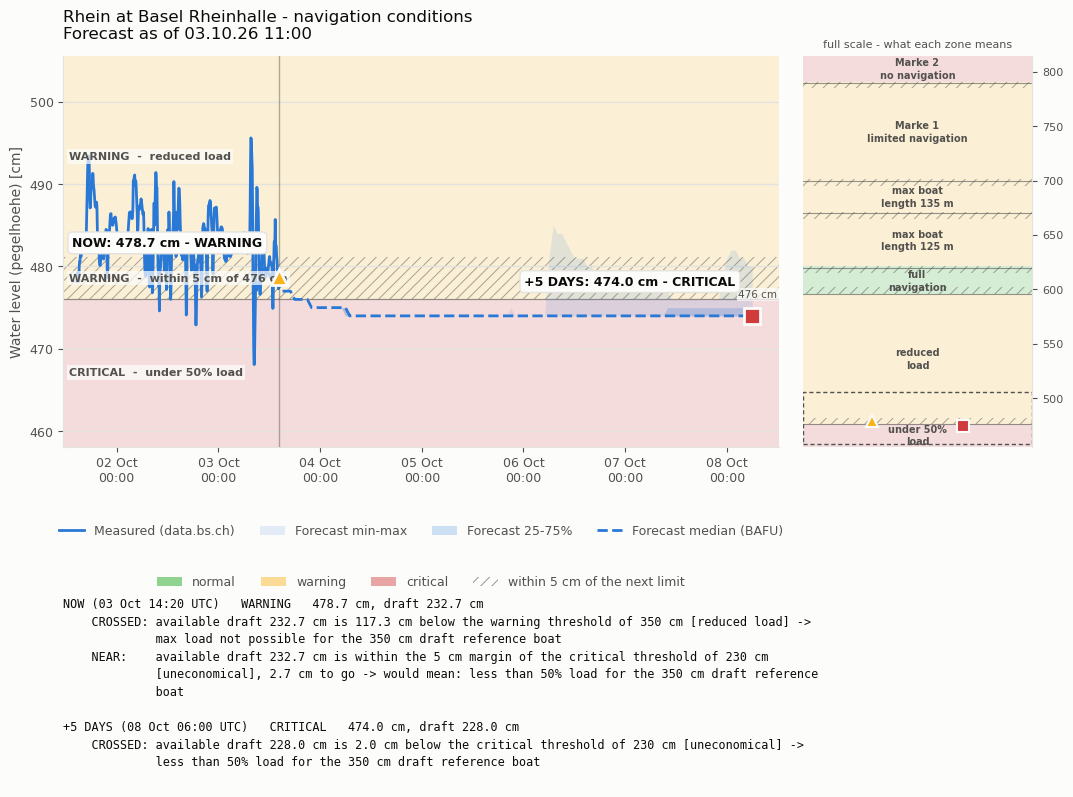

In [34]:
import textwrap

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import numpy as np

# Reserved status colours - these mean a state, never a series. Colour carries
# what is in force; the 45 deg texture is a separate channel that carries
# "within MARGIN_CM of the next limit", whatever zone you are already in.
STATUS_COLOR = {"normal": "#0ca30c", "watch": "#0ca30c",
                "warning": "#fab219", "critical": "#d03b3b"}
MARGIN_HATCH = "///"
plt.rcParams["hatch.linewidth"] = 0.7
# Second channel, so the state never rests on colour alone.
STATUS_MARKER = {"normal": "o", "watch": "D", "warning": "^", "critical": "s"}
SERIES_COLOR = "#2a78d6"   # one measure, one hue: measured solid, forecast dashed
SURFACE = "#fcfcfb"
INK, INK_SOFT, GRID = "#0b0b0b", "#52514e", "#e3e2df"


def _status_bands(low, high, step=0.5):
    """Contiguous (y0, y1, status, approaching) bands, read off assess_conditions.

    `approaching` is the limit (in pegelhoehe cm) that the band is within
    MARGIN_CM of, or None. It is independent of `status`: a level already inside
    the warning zone can still be closing on the critical one, and that band gets
    the texture too. Sampling the real function keeps picture and verdict in sync.
    """
    levels = np.arange(low, high + step, step)
    keys = []
    for value in levels:
        assessment = assess_conditions(float(value))
        near = next((f for f in assessment["findings"] if f["state"] == "margin"), None)
        limit = None
        if near is not None:  # findings are most-severe-first
            limit = near["limit"] + (DRAFT_OFFSET
                                     if near["quantity"] == "available draft" else 0)
        keys.append((assessment["status"], limit))
    bands, start = [], 0
    for i in range(1, len(levels) + 1):
        if i == len(levels) or keys[i] != keys[start]:
            bands.append((float(levels[start]), float(levels[min(i, len(levels) - 1)]),
                          keys[start][0], keys[start][1]))
            start = i
    return bands


def _paint_band(axes, y0, y1, status, approaching, zorder=0):
    """Fill a band by status, and texture it when a limit is within MARGIN_CM."""
    axes.axhspan(y0, y1, color=STATUS_COLOR[status], alpha=0.16, linewidth=0,
                 zorder=zorder)
    if approaching is not None:
        axes.axhspan(y0, y1, facecolor="none", edgecolor=INK_SOFT, linewidth=0,
                     hatch=MARGIN_HATCH, alpha=0.5, zorder=zorder)


def _restriction_zones(low, high):
    """(y0, y1, text) spans between consecutive limits, labelled by the restriction.

    The short labels live on the threshold rules themselves, so the chart and the
    verdict keep quoting the same source.
    """
    highs = sorted(HIGH_THRESHOLDS, key=lambda r: r["limit"])
    lows = sorted(LOW_THRESHOLDS, key=lambda r: -r["limit"])
    zones = [(lows[0]["limit"] + DRAFT_OFFSET, highs[0]["limit"], "full\nnavigation")]
    for i, rule in enumerate(highs):
        top = highs[i + 1]["limit"] if i + 1 < len(highs) else max(high, rule["limit"] + 1)
        zones.append((rule["limit"], top, rule["short"]))
    for i, rule in enumerate(lows):
        bottom = (lows[i + 1]["limit"] + DRAFT_OFFSET if i + 1 < len(lows)
                  else min(low, rule["limit"] + DRAFT_OFFSET - 1))
        zones.append((bottom, rule["limit"] + DRAFT_OFFSET, rule["short"]))
    return [(max(y0, low), min(y1, high), text) for y0, y1, text in zones
            if y1 > low and y0 < high]


def plot_conditions(result=None, df=None, days_ahead=5, figsize=(12.5, 9.5)):
    """Plot the threshold zones with the current and forecast levels marked.

    Zones are coloured by what is in force (green normal, yellow warning, red
    critical) and labelled in text; a 45 deg texture over any of them means the
    next limit is within MARGIN_CM. The two points carry the status
    colour plus a distinct marker shape, and every finding is written out in
    full underneath.

    Pass a result from forecast_conditions_bafu(), or let it fetch one.
    """
    if result is None:
        result = forecast_conditions_bafu(df=df, days_ahead=days_ahead)
    series = result["series"]
    now, future = result["latest"], result["forecast"]

    fig = plt.figure(figsize=figsize, facecolor=SURFACE)
    grid = fig.add_gridspec(2, 2, height_ratios=[3, 1.45], width_ratios=[5, 1.6],
                            hspace=0.52, wspace=0.05)
    ax = fig.add_subplot(grid[0, 0], facecolor=SURFACE)
    scale = fig.add_subplot(grid[0, 1], facecolor=SURFACE)
    notes = fig.add_subplot(grid[1, :])
    notes.axis("off")

    # --- y range: the data, plus whatever boundary it is heading towards ------
    values = [now["pegelhoehe"], future["pegelhoehe"]]
    for column in ("median", "min", "max"):
        if column in series:
            values += series[column].tolist()
    if df is not None and not df.empty:
        values += df["pegelhoehe"].dropna().tolist()
    low, high = min(values) - 10, max(values) + 10
    edges = [t["limit"] for t in HIGH_THRESHOLDS] + \
            [t["limit"] + DRAFT_OFFSET for t in LOW_THRESHOLDS]
    below = [e for e in edges if e <= min(values)]
    above = [e for e in edges if e >= max(values)]
    if below and min(values) - max(below) < 60:
        low = min(low, max(below) - 8)
    if above and min(above) - max(values) < 60:
        high = max(high, min(above) + 8)

    # --- zones ----------------------------------------------------------------
    restrictions = _restriction_zones(low, high)

    def restriction_at(y):
        for r0, r1, text in restrictions:
            if r0 <= y < r1:
                return text.replace("\n", " ")
        return ""

    for y0, y1, status, approaching in _status_bands(low, high):
        _paint_band(ax, y0, y1, status, approaching)
        if (y1 - y0) / (high - low) > 0.045:  # only label a band a label fits in
            if approaching is not None:
                text = (f"{status.upper()}  -  within {MARGIN_CM:.0f} cm "
                        f"of {approaching:.0f} cm")
            elif status in ("warning", "critical"):
                text = f"{status.upper()}  -  {restriction_at((y0 + y1) / 2)}"
            else:
                text = "NORMAL  -  full navigation"
            ax.text(0.008, (y0 + y1) / 2, text,
                    transform=ax.get_yaxis_transform(), ha="left", va="center",
                    fontsize=8, color=INK_SOFT, weight="bold", zorder=5,
                    bbox=dict(boxstyle="square,pad=0.22", facecolor=SURFACE,
                              edgecolor="none", alpha=0.72))

    for edge in edges:  # the limits themselves, not just the colour change
        if low < edge < high:
            ax.axhline(edge, color=INK_SOFT, linewidth=0.9, alpha=0.6, zorder=1)
            ax.text(0.997, edge, f"{edge:.0f} cm", transform=ax.get_yaxis_transform(),
                    ha="right", va="bottom", fontsize=7.5, color=INK_SOFT, zorder=5,
                    bbox=dict(boxstyle="square,pad=0.15", facecolor=SURFACE,
                              edgecolor="none", alpha=0.75))

    # --- the measured series and the forecast --------------------------------
    if df is not None and not df.empty:
        ax.plot(df["timestamp"], df["pegelhoehe"], color=SERIES_COLOR, linewidth=2,
                zorder=4, label="Measured (data.bs.ch)")
    if {"min", "max"}.issubset(series.columns):
        ax.fill_between(series["timestamp"], series["min"], series["max"],
                        color=SERIES_COLOR, alpha=0.12, linewidth=0, zorder=2,
                        label="Forecast min-max")
    if {"p25", "p75"}.issubset(series.columns):
        ax.fill_between(series["timestamp"], series["p25"], series["p75"],
                        color=SERIES_COLOR, alpha=0.22, linewidth=0, zorder=3,
                        label="Forecast 25-75%")
    ax.plot(series["timestamp"], series["median"], color=SERIES_COLOR, linewidth=2,
            linestyle="--", zorder=4, label="Forecast median (BAFU)")

    # --- the two points -------------------------------------------------------
    x_start = (df["timestamp"].iloc[0] if df is not None and not df.empty
               else series["timestamp"].iloc[0])
    x_end = series["timestamp"].iloc[-1]
    width = (x_end - x_start) or pd.Timedelta(hours=1)
    for point, tag in ((now, "NOW"), (future, f"+{days_ahead} DAYS")):
        # label points inward, so one near an edge cannot run off the figure
        near_left = (pd.Timestamp(point["timestamp"]) - x_start) / width < 0.2
        offset = (12, 20) if near_left else (-12, 20)
        status = point["assessment"]["status"]
        ax.plot(point["timestamp"], point["pegelhoehe"],
                marker=STATUS_MARKER.get(status, "o"), markersize=11,
                color=STATUS_COLOR.get(status, INK), markeredgecolor=SURFACE,
                markeredgewidth=2, linestyle="none", zorder=6)
        ax.annotate(f"{tag}: {point['pegelhoehe']:.1f} cm - {status.upper()}",
                    xy=(point["timestamp"], point["pegelhoehe"]),
                    xytext=offset, textcoords="offset points",
                    ha="right" if offset[0] < 0 else "left",
                    va="bottom" if offset[1] > 0 else "top",
                    fontsize=9, color=INK, weight="bold", zorder=7,
                    bbox=dict(boxstyle="round,pad=0.35", facecolor=SURFACE,
                              edgecolor=GRID, linewidth=1))
    ax.axvline(now["timestamp"], color=INK_SOFT, linewidth=1, alpha=0.45, zorder=5)

    # --- chrome ---------------------------------------------------------------
    ax.set_ylim(low, high)
    ax.set_ylabel("Water level (pegelhoehe) [cm]", fontsize=10, color=INK_SOFT)
    ax.set_title("Rhein at Basel Rheinhalle - navigation conditions\n"
                 f"{series.attrs.get('issued', '')}",
                 fontsize=12, color=INK, loc="left", pad=12)
    ax.grid(axis="y", color=GRID, linewidth=1)
    ax.set_axisbelow(True)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_color(GRID)
    ax.tick_params(colors=INK_SOFT, labelsize=9)
    ax.set_xlim(x_start - width * 0.02, x_end + width * 0.04)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b\n%H:%M"))
    series_key = ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.17),
                           fontsize=9, frameon=False, ncol=4, labelcolor=INK_SOFT)
    ax.add_artist(series_key)
    ax.legend(handles=[Patch(facecolor=STATUS_COLOR["normal"], alpha=0.45,
                             label="normal", linewidth=0),
                       Patch(facecolor=STATUS_COLOR["warning"], alpha=0.45,
                             label="warning", linewidth=0),
                       Patch(facecolor=STATUS_COLOR["critical"], alpha=0.45,
                             label="critical", linewidth=0),
                       Patch(facecolor=SURFACE, hatch=MARGIN_HATCH,
                             edgecolor=INK_SOFT, linewidth=0, alpha=0.6,
                             label=f"within {MARGIN_CM:.0f} cm of the next limit")],
              loc="upper center", bbox_to_anchor=(0.5, -0.30), fontsize=9,
              frameon=False, ncol=4, labelcolor=INK_SOFT)

    # --- context strip: every zone, always, whatever the data is doing --------
    s_low, s_high = min(low, 455), max(high, max(edges) + 25)
    for y0, y1, status, approaching in _status_bands(s_low, s_high, step=1.0):
        _paint_band(scale, y0, y1, status, approaching)
    for y0, y1, text in _restriction_zones(s_low, s_high):
        if (y1 - y0) / (s_high - s_low) > 0.035:
            scale.text(0.5, (y0 + y1) / 2, text, ha="center", va="center",
                       transform=scale.get_yaxis_transform(), fontsize=7,
                       color=INK_SOFT, weight="bold", linespacing=1.3)
    for edge in edges:
        if s_low < edge < s_high:
            scale.axhline(edge, color=INK_SOFT, linewidth=0.8, alpha=0.6, zorder=2)
    scale.axhspan(low, high, facecolor="none", edgecolor=INK_SOFT, linewidth=1,
                  linestyle=(0, (3, 2)), zorder=4)
    for point, x in ((now, 0.3), (future, 0.7)):
        status = point["assessment"]["status"]
        scale.plot([x], [point["pegelhoehe"]], transform=scale.get_yaxis_transform(),
                   marker=STATUS_MARKER.get(status, "o"), markersize=8,
                   color=STATUS_COLOR.get(status, INK), markeredgecolor=SURFACE,
                   markeredgewidth=1.5, linestyle="none", zorder=6)
    scale.set_ylim(s_low, s_high)
    scale.set_xticks([])
    scale.yaxis.tick_right()
    scale.tick_params(colors=INK_SOFT, labelsize=8)
    for side in ("top", "left", "bottom"):
        scale.spines[side].set_visible(False)
    scale.spines["right"].set_color(GRID)
    scale.set_title("full scale - what each zone means", fontsize=8,
                    color=INK_SOFT, pad=6)

    # --- the detail, in words -------------------------------------------------
    lines = []
    for point, tag in ((now, "NOW"), (future, f"+{days_ahead} DAYS")):
        assessment = point["assessment"]
        stamp = pd.Timestamp(point["timestamp"]).strftime("%d %b %H:%M UTC")
        lines.append(f"{tag} ({stamp})   {assessment['status'].upper()}   "
                     f"{point['pegelhoehe']:.1f} cm, "
                     f"draft {assessment['draft_cm']:.1f} cm")
        if assessment["normal"]:
            lines.append(f"    no threshold crossed, none within the "
                         f"{MARGIN_CM:.0f} cm margin")
        else:
            for finding in assessment["findings"]:
                prefix = ("    CROSSED: " if finding["state"] == "breached"
                          else "    NEAR:    ")
                lines += textwrap.wrap(finding["message"], 108,
                                       initial_indent=prefix,
                                       subsequent_indent=" " * 13)
        lines.append("")
    notes.text(0, 1, "\n".join(lines), transform=notes.transAxes, va="top",
               ha="left", fontsize=8.5, family="monospace", color=INK,
               linespacing=1.45)
    return fig


fig = plot_conditions(df=df)
plt.show()


,timestamp,abfluss,pegelhoehe,pegel
0,2026-10-01 14:35:00+00:00,340.204,478.2,244.782
1,2026-10-01 14:40:00+00:00,342.487,478.5,244.785
2,2026-10-01 14:45:00+00:00,344.770,478.8,244.788
3,2026-10-01 14:50:00+00:00,348.569,479.3,244.793
4,2026-10-01 14:55:00+00:00,346.292,479.0,244.790
...,...,...,...,...
569,2026-10-03 14:00:00+00:00,347.051,479.1,244.791
570,2026-10-03 14:05:00+00:00,343.248,478.6,244.786
571,2026-10-03 14:10:00+00:00,333.340,477.3,244.773
572,2026-10-03 14:15:00+00:00,334.103,477.4,244.774
